# Quick-start guide

FastEMRIWaveforms (FEW) is a framework for constructing multivoice waveform models, such as those accessible with gravitational self-force theory. FEW contains in-built models that describe waveforms for compact binary inspirals at the adiabatic order. As these models do not yet support generic systems, the Augmented Analytic Kludge (AAK) with a fifth-order post-Newtonian trajectory is also available (but is less accurate than these adiabatic models.)

This quick-start guide will demonstrate some of FEW's main features, particularly
- Waveforms (time and frequency domains)
- Inspiral trajectories

See the rest of the documentation for more complete examples of the functionality of each module.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import few

cfg_set = few.get_config_setter(reset=True)

# Uncomment if you want to force CPU or GPU usage
# Leave commented to let FEW automatically select the best available hardware
#   - To force CPU usage:
# cfg_set.enable_backends("cpu")
#   - To force GPU usage with CUDA 12.x
# cfg_set.enable_backends("cuda12x", "cpu")
#   - To force GPU usage with CUDA 11.x
# cfg_set.enable_backends("cuda11x", "cpu")

## Waveforms

In [2]:
# Wrapper for EMRI waveform models
from few.waveform import GenerateEMRIWaveform

# time domain
td_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux",
    sum_kwargs=dict(pad_output=True),
    return_list=True  # if False, returns as h+ -ihx
)

# frequency domain (SPA)
fd_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux",
    sum_kwargs=dict(pad_output=True, output_type="fd", odd_len=True),  # odd_len=True required for frequency domain
    return_list=True  # return_list=True required for frequency domain
)

# the "force_backend" kwarg can be used to force e.g. "cpu" usage.

In [3]:
td_gen.stock_waveform_options

['FastSchwarzschildEccentricFlux',
 'FastSchwarzschildEccentricFluxBicubic',
 'SlowSchwarzschildEccentricFlux',
 'FastKerrEccentricEquatorialFlux',
 'Pn5AAKWaveform']

In [4]:
# define the intrinsic parameters
m1 = 1e6  # central object mass in solar masses
m2 = 10.0  # secondary object mass in solar masses
a = 0.9  # dimensionless spin parameter of the central object
p0 = 4.5  # initial semi-latus rectum
e0 = 0.5  # eccentricity
xI0 = 1.0  # cosine(inclination) of orbital plane --- set to one for equatorial orbits

#  extrinsic parameters
dist = 1.0  # distance in Gpc
qS = np.pi / 3  # polar sky angle (complement to ecliptic latitude)
phiS = np.pi / 3  # azimuthal viewing angle (ecliptic longitude)
qK = np.pi / 3  # polar spin-vector angle
phiK = np.pi / 3  # azimuthal spin-vector angle

# initial orbital phases
Phi_phi0 = np.pi / 3   # enters mode phasing as m * Phi_phi0
Phi_theta0 = 0.0  # enters mode phasing as k * Phi_theta0 (not used for equatorial orbits)
Phi_r0 = np.pi / 3  # enters mode phasing as n * Phi_r0

# waveform build parameters
Tobs = 0.1  # observation time, if the inspiral is shorter, then it will be zero-padded
dt = 5.0  # sampling cadence (seconds)
mode_selection_threshold = 1e-3  # tunes mode content: target mismatch is ~ mode_selection_threshold

waveform_kwargs = {"T": Tobs,"dt": dt,"mode_selection_threshold": mode_selection_threshold}

parameters = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

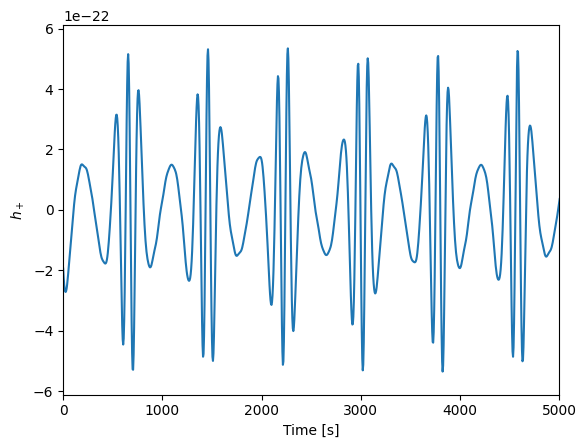

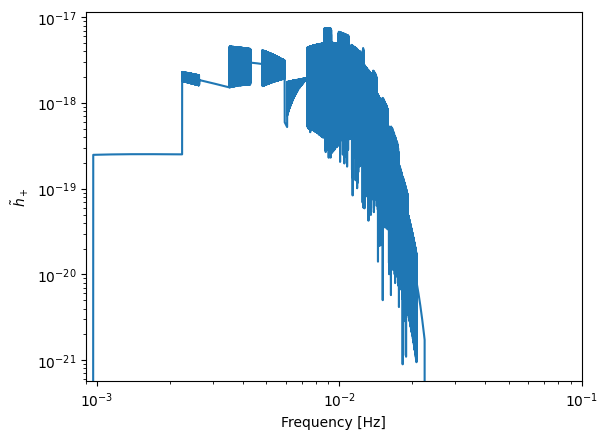

In [5]:
waveform_td = td_gen(*parameters, **waveform_kwargs)
time_array = np.arange(len(waveform_td[0])) * dt

plt.figure()
plt.plot(time_array, waveform_td[0])
plt.xlim(0, 5000)
plt.xlabel("Time [s]")
plt.ylabel("$h_+ $")
plt.show()

waveform_fd = fd_gen(*parameters, **waveform_kwargs)
waveform_fd_f_pos = fd_gen(*parameters, mask_positive=True, **waveform_kwargs)  # returns only non-negative frequencies
frequency_array = fd_gen.waveform_generator.create_waveform.frequency

plt.figure()
plt.loglog(frequency_array[frequency_array >= 0], np.abs(waveform_fd_f_pos[0]))
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$\tilde{h}_+$")
plt.xlim(9e-4, 1e-1)
plt.show()

Adjusting `mode_selection_threshold` significantly impacts the computational cost of the waveform.

In [6]:
from few.utils.utility import get_mismatch

waveform_td = td_gen(*parameters, T=Tobs, dt=dt, mode_selection_threshold=1e-5)
waveform_td_faster = td_gen(*parameters, T=Tobs, dt=dt, mode_selection_threshold=1e-2)

get_mismatch(waveform_td[0], waveform_td_faster[0])  # a bit less than 1e-2

np.float64(0.0015184939984809187)

In [7]:
%timeit waveform_td_faster = td_gen(*parameters, T=Tobs, dt=dt, mode_selection_threshold=1e-2)

215 ms ± 16.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [8]:
%timeit waveform_td = td_gen(*parameters, T=Tobs, dt=dt, mode_selection_threshold=1e-5)

398 ms ± 21.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Trajectories

In [9]:
# trajectory generator
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import _STOCK_TRAJECTORY_OPTIONS
from few.utils.constants import YRSID_SI
from few.utils.utility import get_p_at_t

list(_STOCK_TRAJECTORY_OPTIONS.keys())

['SchwarzEccFlux', 'KerrEccEqFlux', 'PN5']

In [10]:
traj_gen = EMRIInspiral(func="KerrEccEqFlux")

In [11]:
# generate trajectory, using parameters defined in the waveform step
T_traj = 1.

traj_out = traj_gen(
    m1,
    m2,
    a,
    p0,
    e0,
    xI0,
    T=T_traj,
)

# output ordering
t, p, e, x, Phi_phi, Phi_theta, Phi_r = traj_out
t[-1] / YRSID_SI, T_traj  # stops early if it reaches the separatrix (few.utils.geodesic.get_separatrix)

(np.float64(0.14533585241191702), 1.0)

In [12]:
from few.utils.geodesic import get_separatrix
p[-1] - get_separatrix(a, e[-1], x[-1])  # this model stops 0.002 from the separatrix

np.float64(0.001999999999986901)

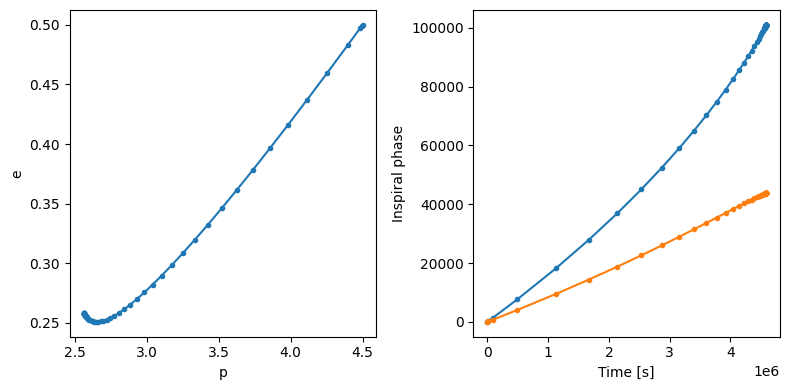

In [13]:
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.plot(p, e, '.-')
plt.xlabel("p")
plt.ylabel("e")
plt.subplot(122)
plt.plot(t, Phi_phi, '.-')
plt.plot(t, Phi_r, '.-')
plt.xlabel("Time [s]")
plt.ylabel("Inspiral phase")

plt.tight_layout()

Trajectories (and therefore waveforms) that plunge after a certain time are often useful:

In [14]:
p0_plunge = get_p_at_t(
    traj_gen,
    T_traj,
    [m1, m2, a, e0, xI0]
)

traj_out = traj_gen(
    m1,
    m2,
    a,
    p0_plunge,
    e0,
    xI0,
    T=T_traj,
)

t2, p2, e2, x2, Phi_phi2, Phi_theta2, Phi_r2 = traj_out

t2[-1] / YRSID_SI, T_traj  # stops right at the separatrix

(np.float64(1.0), 1.0)

In [15]:
# accessing the trajectory solution and its derivatives

t_new = np.linspace(0, t2[-1], 200)

traj_interp = traj_gen.inspiral_generator.eval_integrator_spline(t_new)
traj_interp_deriv = traj_gen.inspiral_generator.eval_integrator_derivative_spline(t_new, order=1)

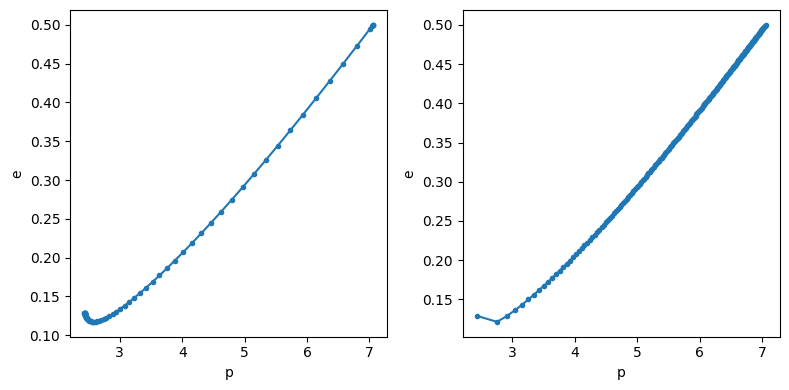

In [16]:
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.plot(p2, e2, '.-')
plt.xlabel("p")
plt.ylabel("e")
plt.subplot(122)
plt.plot(traj_interp[:,0], traj_interp[:,1], '.-')
plt.xlabel("p")
plt.ylabel("e")

plt.tight_layout()

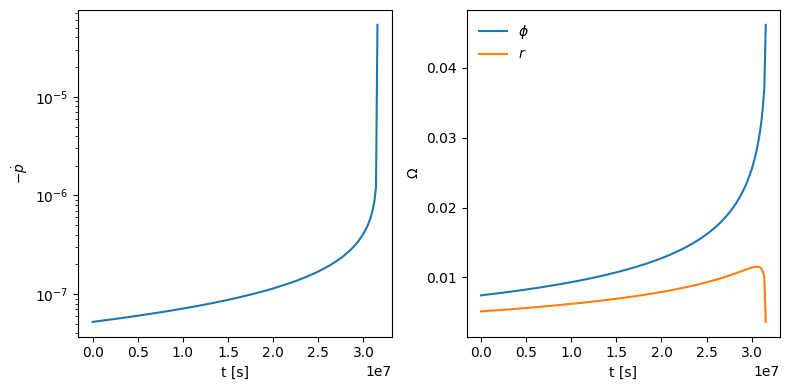

In [19]:
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.semilogy(t_new, -traj_interp_deriv[:,0])
plt.xlabel("t [s]")
plt.ylabel(r"$-\dot{p}$")
plt.subplot(122)
plt.plot(t_new, traj_interp_deriv[:,3], label=r'$\phi$')
plt.plot(t_new, traj_interp_deriv[:,5], label=r'$r$')
plt.legend(frameon=False)
plt.xlabel("t [s]")
plt.ylabel(r"$\Omega$")

plt.tight_layout()

In [20]:
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq

In [21]:
amp_gen = AmpInterpKerrEccEq()

In [24]:
amp_gen(
    0.7,
    10.,
    0.3,
    1.,
).shape

(1, 6993)

In [26]:
amp_gen.special_index_map_arr[2,2,0]

np.int32(1165)